## **Tutorial**

---

### **Advection–Diffusion Equation Unidimensional**

* **Domain:**
  $\Omega = [0,1]$

* **Governing equation:**
  $
  \mathrm{Pe} \,\phi_x - \phi_{xx} = 0, \quad x \in \Omega
  $

* **Boundary conditions:**
  $
  \phi(0) = 1 \quad \text{and} \quad \phi(1) = 0
  $


### **1. Packages**
---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from typing import List, Mapping

from bernet.core import standard as std
from bernet.core import sampler as sp
from bernet.core import operator as operator

from bernet.utils.processing import mse

### **2. Hyperparameters**
---

In [2]:
#-- Model
neurons = [2, 5, 5, 1]
activation = torch.nn.Tanh()

#-- Loss
scale = 10.0

#-- Sampler
interior_h = 0.01
boundary_h = 0.01

#-- Optimizer
learning_rate = 1e-3
weight_decay = 1e-6

#-- Trainer
num_epochs = 300
verbose = True
filename = "advection-diffusion-op.log"

### **3. Implementation**
---

**Analytical Solution**

- Function definition

In [3]:
def analytical_solution(x: np.ndarray, peclet: float, tol: float = 1e-6) -> np.ndarray:
    return ( 1 - np.exp( (peclet + tol) * (x - 1) ) ) / ( 1 - np.exp(-(peclet + tol)) )

- Ploting solution

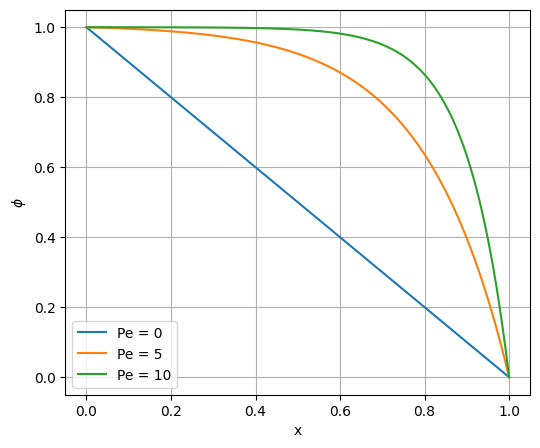

In [4]:
#-- Define the spatial domain
x = np.linspace(0, 1, 100)

#-- Compute the analytical solution
phi_Pe00 = analytical_solution(x=x, peclet=0)
phi_Pe05 = analytical_solution(x=x, peclet=5)
phi_Pe10 = analytical_solution(x=x, peclet=10)

#-- Plot the solution
plt.figure(figsize=(6, 5))
plt.plot(x, phi_Pe00, label="Pe = 0")
plt.plot(x, phi_Pe05, label="Pe = 5")
plt.plot(x, phi_Pe10, label="Pe = 10")
plt.xlabel("x")
plt.ylabel(r"$\phi$")
plt.legend()
plt.grid()
plt.show()

**Model**

In [5]:
class Model(torch.nn.Module):

    def __init__(
            self,
            neurons: List[int],
            activation: torch.nn.Module,
        ) -> None:
        super(Model, self).__init__()

        #-- Define a sequential model
        self.net = torch.nn.Sequential()

        #-- Add layers
        for i in range(len(neurons) - 1):
            self.net.append(torch.nn.Linear(neurons[i], neurons[i + 1]))
            if i < len(neurons) - 2:
                self.net.append(activation)
        
        return

    def forward(
            self,
            x: torch.Tensor,
        ) -> torch.Tensor:

        #-- Forward pass
        phi = self.net(x)

        return phi

**Loss**

In [6]:
class Loss(operator.LossBASE):

    def __init__(self, operator: operator.Operator, scale: float):
        super().__init__(operator)
        self._scale = scale
        return
    
    @mse()
    def residual(self, model: torch.nn.Module, batch: Mapping[str, torch.Tensor]) -> torch.Tensor:
        super().residual(model, batch["x"])

        #-- Get operator
        op = self.get_operator()

        #-- Get parameters
        x = self.get_parameter("x")
        peclet = self._scale * self.get_parameter("peclet")
        phi = self.get_parameter("phi")

        loss = (peclet * op.partial(phi, x) - op.partial2(phi, x)) / (1 + peclet)

        return loss
    
    @mse()
    def boundary(self, model: torch.nn.Module, batch: Mapping[str, torch.Tensor]) -> torch.Tensor:
        super().boundary(model, torch.cat([batch["x"], batch["y"]], dim=1))

        #-- Get parameters
        phi = self.get_parameter("phi")
        data = self.get_parameter("data")

        return phi - data
    
    @mse()
    def observational(self, model: torch.nn.Module, batch: Mapping[str, torch.Tensor]) -> torch.Tensor:
        super().observational(model, torch.cat([batch["x"], batch["y"]], dim=1))

        #-- Get parameters
        phi = self.get_parameter("phi")
        data = self.get_parameter("data")

        return phi - data

### **4. Training**
---

Parameters

In [7]:
#-- Define operator
op = operator.Operator()

#-- Add parameters
op.set_parameter("x", axis=0, io="in", requires_grad=True)
op.set_parameter("peclet", axis=1, io="in")
op.set_parameter("phi", axis=0, io="out")

op.set_parameter("data", axis=2, io="none", losses=["boundary", "observational"])

#-- Initialize parameters
model = Model(neurons, activation)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
loss = Loss(op, scale)

sampler = sp.Square(
    interior_h, boundary_h,
    keep_ratio=False,
    func=lambda x: analytical_solution(x[:, 0], scale * x[:, 1]).reshape(-1, 1),
    ratio_ob=0.1,
    remove=["bottom", "top"],
)

trainer = std.Trainer(
    model, sampler, loss, optimizer,
    metrics=["mse", "mae"],
    logger=std.Logger(),
    initialization="xavier_uniform",
)

Fit

In [8]:
#-- Realiza o treinamento
data = trainer.fit(num_epochs, verbose=verbose)

#-- Save training data
trainer.save(filename)

Epoch 1/300; | ILoss: 4.892e-01 (3.440e-02; 3.123e-01, 0.000e+00, 1.425e-01) | [mse: 6.223e-02, mae: 2.281e-01]
Epoch 2/300; | ILoss: 2.692e-01 (4.678e-02; 1.659e-01, 0.000e+00, 5.655e-02) | [mse: 5.071e-02, mae: 2.097e-01]
Epoch 3/300; | ILoss: 2.475e-01 (5.347e-02; 1.432e-01, 0.000e+00, 5.077e-02) | [mse: 4.425e-02, mae: 1.933e-01]
Epoch 4/300; | ILoss: 2.330e-01 (5.533e-02; 1.335e-01, 0.000e+00, 4.418e-02) | [mse: 3.906e-02, mae: 1.811e-01]
Epoch 5/300; | ILoss: 2.222e-01 (5.880e-02; 1.225e-01, 0.000e+00, 4.100e-02) | [mse: 4.115e-02, mae: 1.860e-01]
Epoch 6/300; | ILoss: 2.133e-01 (6.279e-02; 1.137e-01, 0.000e+00, 3.675e-02) | [mse: 3.720e-02, mae: 1.783e-01]
Epoch 7/300; | ILoss: 2.110e-01 (6.629e-02; 1.089e-01, 0.000e+00, 3.580e-02) | [mse: 3.458e-02, mae: 1.697e-01]
Epoch 8/300; | ILoss: 2.074e-01 (6.863e-02; 1.044e-01, 0.000e+00, 3.430e-02) | [mse: 3.219e-02, mae: 1.643e-01]
Epoch 9/300; | ILoss: 2.028e-01 (6.746e-02; 1.038e-01, 0.000e+00, 3.156e-02) | [mse: 2.771e-02, mae: 1.4

### **5. Results**
---

Training data

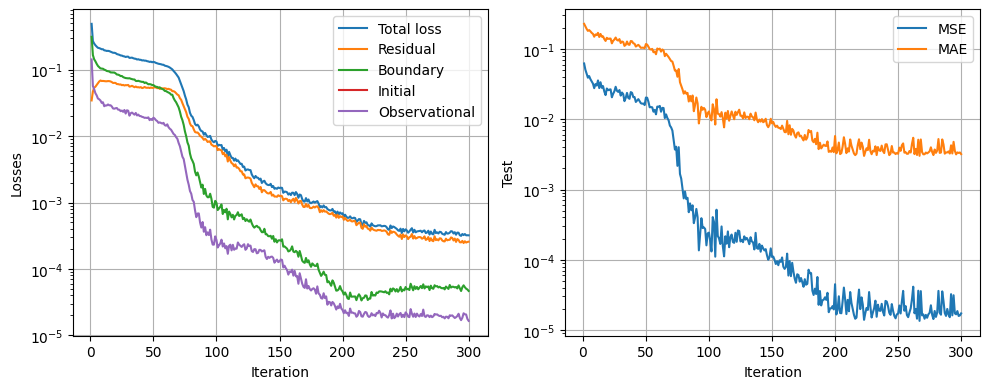

In [9]:
#-- Figures
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

#-  Left plot: Losses
axes[0].plot(data["iteration"], data["loss"], label="Total loss")
axes[0].plot(data["iteration"], data["residual"], label="Residual")
axes[0].plot(data["iteration"], data["boundary"], label="Boundary")
axes[0].plot(data["iteration"], data["initial"], label="Initial")
axes[0].plot(data["iteration"], data["observational"], label="Observational")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Losses")
axes[0].set_yscale("log")
axes[0].legend()
axes[0].grid()

#-  Right plot: Metrics
axes[1].plot(data["iteration"], data["mse [test]"], label="MSE")
axes[1].plot(data["iteration"], data["mae [test]"], label="MAE")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Test")
axes[1].set_yscale("log")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

Field prediction

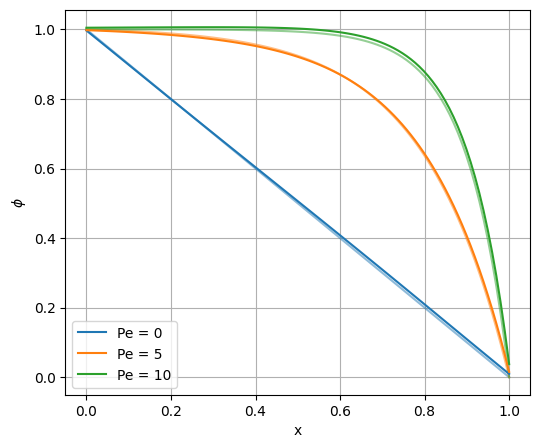

In [10]:
#-- Define the spatial domain
n = 100
x = np.linspace(0, 1, n)

#-- Compute the analytical solution
phi_Pe00 = analytical_solution(x=x, peclet=0)
phi_Pe05 = analytical_solution(x=x, peclet=5)
phi_Pe10 = analytical_solution(x=x, peclet=10)

#-- Predicted solution
model.eval()

x_Pe00 = torch.cat([torch.from_numpy(x).view(-1, 1), torch.zeros(n, 1)], dim=1).to(dtype=torch.float32)
phi_hat_Pe00 = model(x_Pe00).detach().numpy()

x_Pe05 = torch.cat([torch.from_numpy(x).view(-1, 1), 0.5 * torch.ones(n, 1)], dim=1).to(dtype=torch.float32)
phi_hat_Pe05= model(x_Pe05).detach().numpy()

x_Pe10 = torch.cat([torch.from_numpy(x).view(-1, 1), 1.0 * torch.ones(n, 1)], dim=1).to(dtype=torch.float32)
phi_hat_Pe10= model(x_Pe10).detach().numpy()

#-- Plot the solution
plt.figure(figsize=(6, 5))

plt.plot(x, phi_Pe00, color="#1f77b4", alpha=0.5)
plt.plot(x, phi_Pe05, color="#ff7f0e", alpha=0.5)
plt.plot(x, phi_Pe10, color="#2ca02c", alpha=0.5)

plt.plot(x, phi_hat_Pe00, color="#1f77b4", label="Pe = 0")
plt.plot(x, phi_hat_Pe05, color="#ff7f0e", label="Pe = 5")
plt.plot(x, phi_hat_Pe10, color="#2ca02c", label="Pe = 10")

plt.xlabel("x")
plt.ylabel(r"$\phi$")
plt.legend()
plt.grid()
plt.show()